In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey_QCmetric.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 4141747 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [4]:
sc.pp.subsample(adata, fraction=0.05)

In [5]:
adata

AnnData object with n_obs × n_vars = 207087 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [6]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [7]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)

# Logarithmize the data
sc.pp.log1p(adata)

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample_id")

In [10]:
sc.tl.pca(adata)

In [13]:
sc.pp.neighbors(adata)

/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
sc.tl.umap(adata)

In [15]:
adata.obs

,sample_id,barcode,SampleNameOnly,Donor,Multiome,Location,n_counts,n_genes,doublet_score,predicted_doublet,...,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
33913869,B008-A-301,CATTGTAAGTTATCCT-1,B008-A-301,B008,Yes,Ileum,211.0,183,0.116883,False,...,100.000000,4.0,1.609438,1.895735,11.0,2.484907,5.213270,0.0,0.000000,0.00000
196153026,B001-A-201,TGGGCGTCACTCCACT-1,B001-A-201,B001,No,Duodenum,646.0,537,0.095998,False,...,94.272446,13.0,2.639057,2.012384,22.0,3.135494,3.405573,0.0,0.000000,0.00000
14736315,B005-A-501,ACCAAACGTAGATGTA-1,B005-A-501,B005,No,Duodenum,319.0,249,0.125987,False,...,100.000000,32.0,3.496508,10.031347,12.0,2.564949,3.761755,1.0,0.693147,0.31348
104072538,B011-A-301,TGCCATTGTTAGTACG-1,B011-A-301,B011,Yes,Ileum,111.0,98,0.172199,False,...,100.000000,0.0,0.000000,0.000000,11.0,2.484907,9.909910,0.0,0.000000,0.00000
74817281,B012-A-301,CGCACCACAGTAGCCT-1,B012-A-301,B012,Yes,Ileum,1380.0,1015,0.351303,True,...,62.681159,6.0,1.945910,0.434783,46.0,3.850148,3.333333,0.0,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81312881,B004-A-504,GTCTAGACAGCTCCTT-1,B004-A-504,B004,No,Duodenum,548.0,454,0.117766,False,...,100.000000,20.0,3.044523,3.649635,22.0,3.135494,4.014598,0.0,0.000000,0.00000
183645523,B001-A-501,AGTCATGCAAGTCATC-1,B001-A-501,B001,No,Ascending,273.0,228,0.110290,False,...,100.000000,11.0,2.484907,4.029304,3.0,1.386294,1.098901,0.0,0.000000,0.00000
84827265,B004-A-104,ATCACGATCTACCTTA-1,B004-A-104,B004,No,Transverse,175.0,156,0.112796,False,...,100.000000,6.0,1.945910,3.428571,3.0,1.386294,1.714286,0.0,0.000000,0.00000
91259258,B011-A-401,CAATCTAAGCTCCTAC-1,B011-A-401,B011,Yes,Mid-jejunum,415.0,325,0.138082,False,...,100.000000,1.0,0.693147,0.240964,78.0,4.369448,18.795181,0.0,0.000000,0.00000


In [16]:
adata.obs.columns

Index(['sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome',
       'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb'],
      dtype='object')

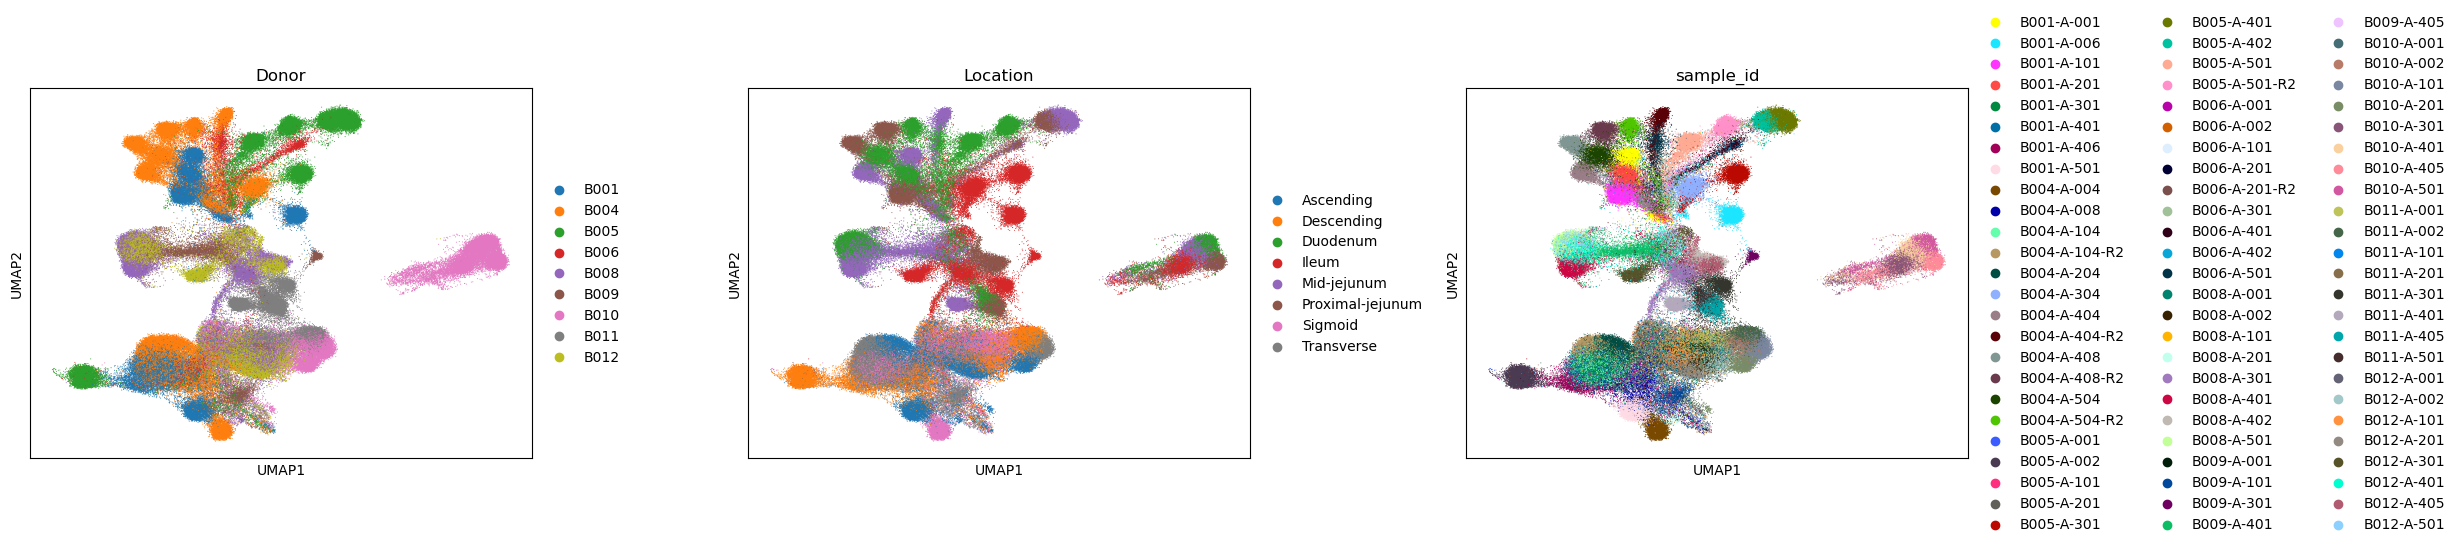

In [17]:
sc.pl.umap(
    adata,
    color=["Donor", "Location", "sample_id"],
    size=2,
    wspace=0.3
)

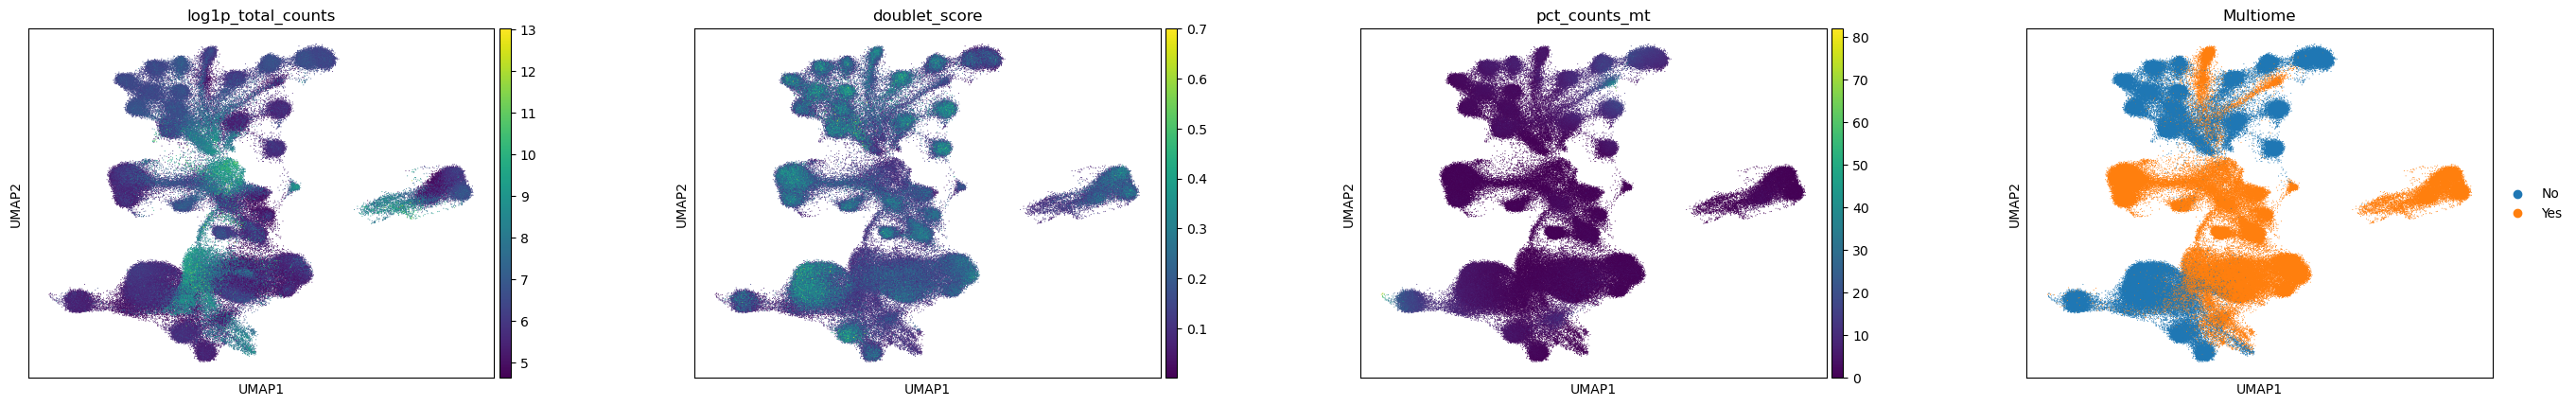

In [18]:
# Plot technical variables
sc.pl.umap(
    adata,
    color=["log1p_total_counts", "doublet_score", "pct_counts_mt", "Multiome"],
    size=2,
    wspace=0.3
)

## Additional QC

In [20]:
idx = (adata.obs.pct_counts_mt < 5) & (adata.obs.doublet_score < 0.3) & (adata.obs.total_counts > 250)

In [22]:
adata = adata[idx]

In [23]:
adata

View of AnnData object with n_obs × n_vars = 89118 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Donor_colors', 'Location_colors', 'sample_id_colors

In [25]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample_id")

/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:744: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [26]:
sc.tl.pca(adata)

In [27]:
sc.pp.neighbors(adata)

In [28]:
sc.tl.umap(adata)

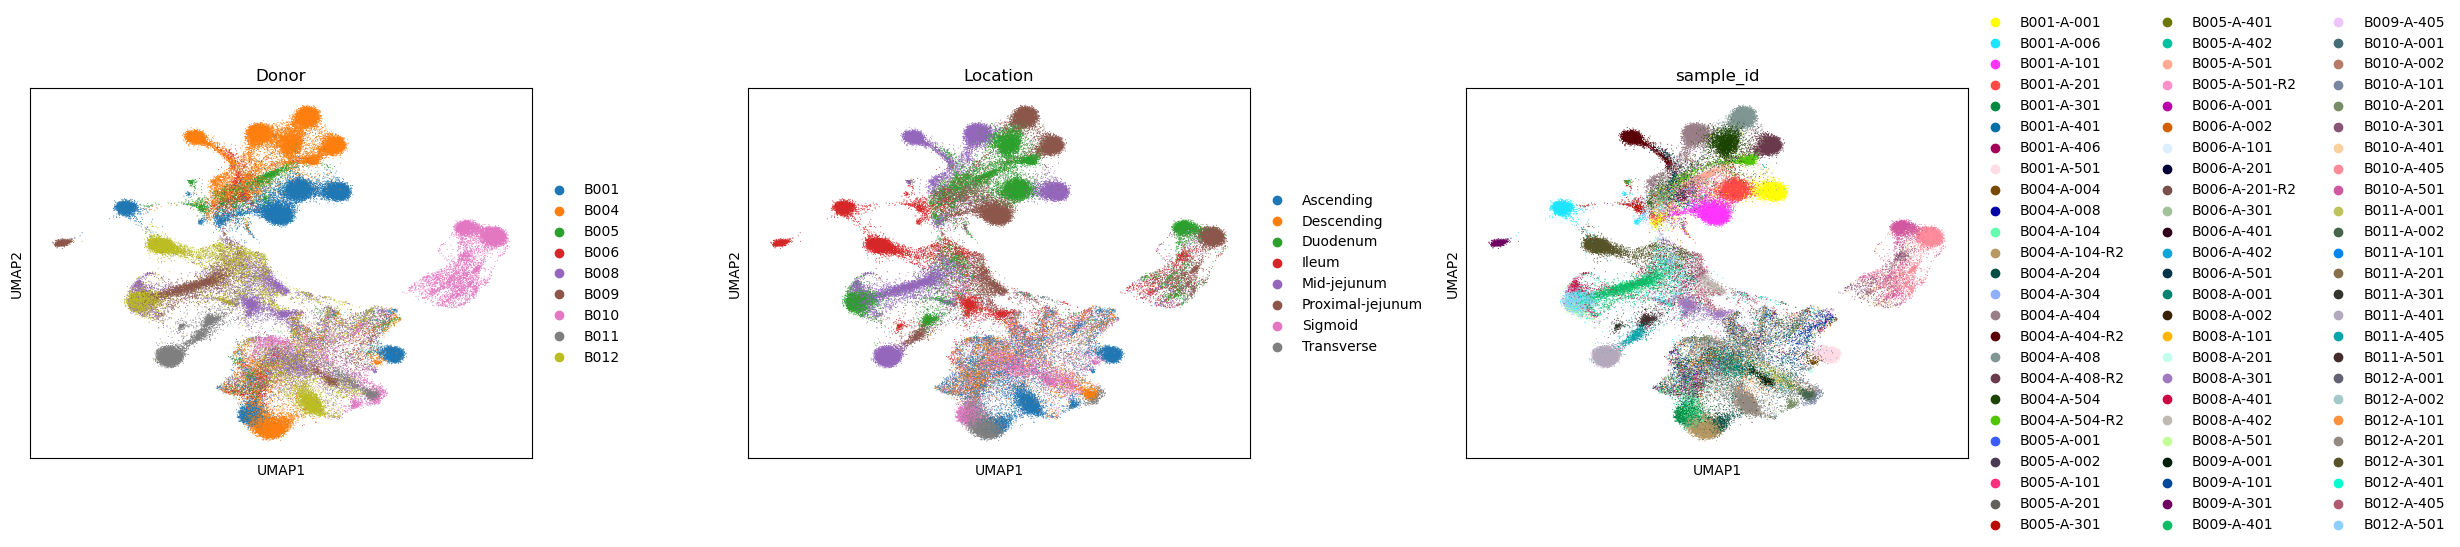

In [29]:
sc.pl.umap(
    adata,
    color=["Donor", "Location", "sample_id"],
    size=2,
    wspace=0.3
)

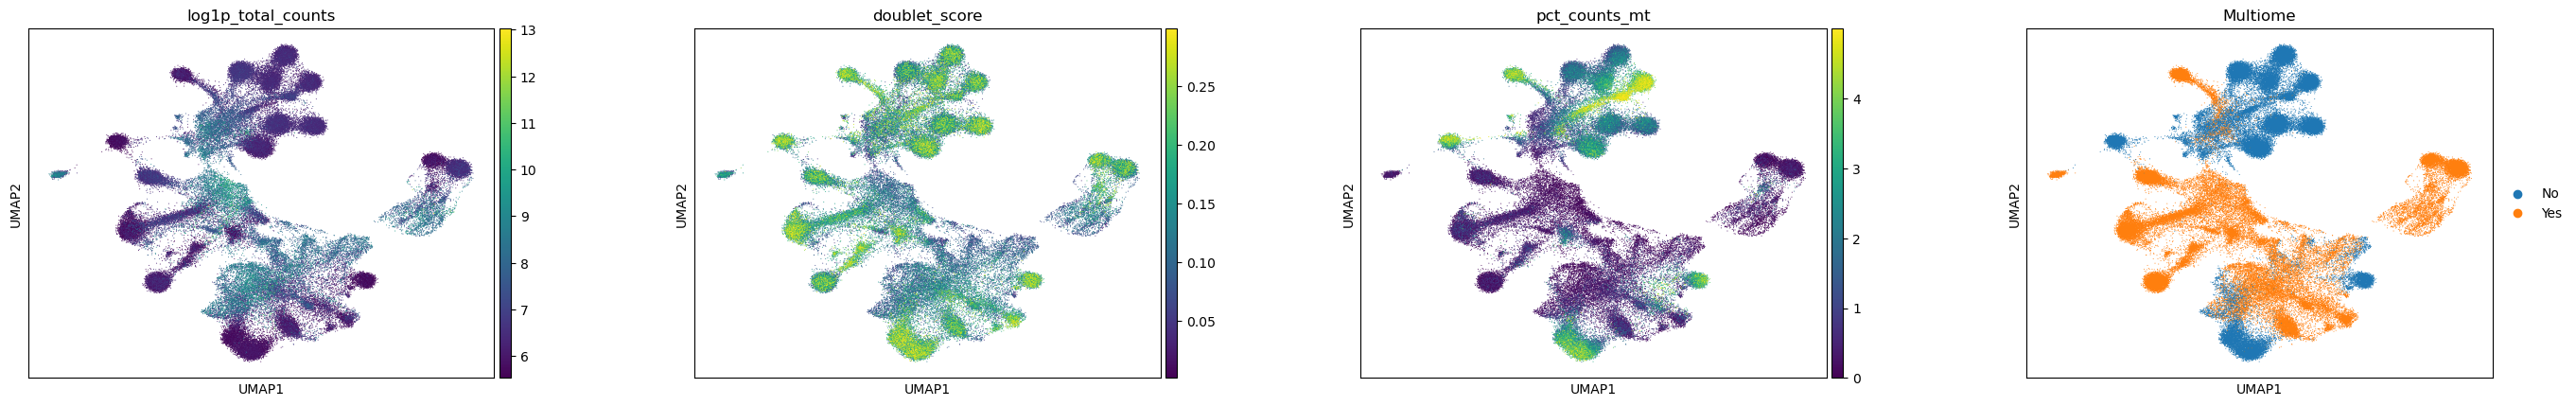

In [30]:
# Plot technical variables
sc.pl.umap(
    adata,
    color=["log1p_total_counts", "doublet_score", "pct_counts_mt", "Multiome"],
    size=2,
    wspace=0.3
)

In [31]:
adata.write_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey_subsampleV2_QCmetric_scanpy.h5ad")